# Mutual Fund Analytics - Fund Performance Analytics

## Bluestock Fintech Internship

### Prepared by: Srinivas Dadi

---

## Objective

This notebook performs Fund Performance Analytics on Mutual Fund datasets using Python, Pandas, NumPy, Matplotlib, Seaborn, and SciPy.

The analysis includes:

- Daily Return Analysis
- CAGR Analysis
- Sharpe Ratio
- Sortino Ratio
- Alpha & Beta Analysis
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison
- Key Insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

plt.style.use("ggplot")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
funds = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [3]:
print("Funds:", funds.shape)
print("NAV:", nav.shape)
print("Performance:", performance.shape)
print("Benchmark:", benchmark.shape)

Funds: (40, 15)
NAV: (46000, 3)
Performance: (40, 19)
Benchmark: (8050, 3)


In [4]:
print("NAV Columns")
print(nav.columns.tolist())

print("\nPerformance Columns")
print(performance.columns.tolist())

print("\nBenchmark Columns")
print(benchmark.columns.tolist())

NAV Columns
['amfi_code', 'date', 'nav']

Performance Columns
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

Benchmark Columns
['date', 'index_name', 'close_value']


## 1. Daily Return Analysis

### Objective

Compute daily returns for each mutual fund scheme using the formula:

Daily Return = (Today's NAV / Previous Day's NAV) − 1

In [5]:
# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Sort data correctly
nav = nav.sort_values(["amfi_code", "date"])

# Calculate daily returns
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

print("Daily Returns Calculated Successfully")

nav.head(10)

Daily Returns Calculated Successfully


,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [6]:
print(nav[["amfi_code", "date", "nav", "daily_return"]].head(10))

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210
5755     100016 2022-01-10  510.7136     -0.008639
5756     100016 2022-01-11  513.5542      0.005562
5757     100016 2022-01-12  512.3195     -0.002404
5758     100016 2022-01-13  510.2445     -0.004050
5759     100016 2022-01-14  514.3636      0.008073


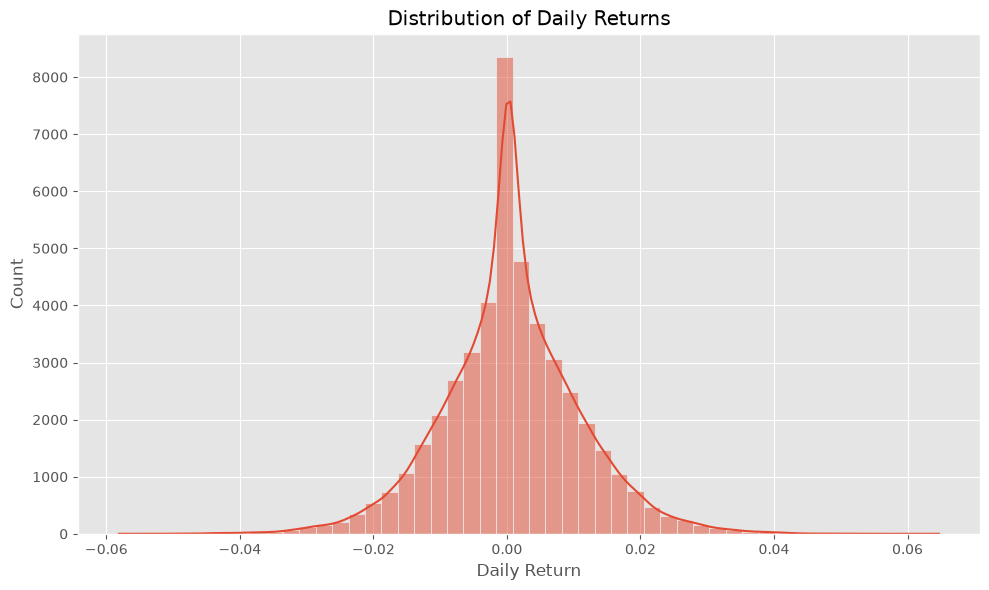

In [7]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")

plt.tight_layout()

plt.savefig("../reports/charts/daily_return_distribution.png")

plt.show()

## 2. CAGR Analysis

### Objective

Analyze and compare the 1-Year, 3-Year and 5-Year returns of mutual fund schemes to evaluate long-term growth performance.

In [8]:
# Select CAGR-related columns
cagr_table = performance[
    [
        "scheme_name",
        "category",
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct"
    ]
]

print("CAGR Comparison Table")

cagr_table.head(10)

CAGR Comparison Table


,scheme_name,category,return_1yr_pct,return_3yr_pct,return_5yr_pct
0,SBI Bluechip Fund - Regular Plan - Growth,Large Cap,12.42,12.36,14.45
1,SBI Bluechip Fund - Direct Plan - Growth,Large Cap,15.25,11.30,14.23
2,SBI Small Cap Fund - Regular Plan - Growth,Small Cap,24.56,23.39,20.67
3,SBI Small Cap Fund - Direct Plan - Growth,Small Cap,20.59,23.14,21.82
4,SBI Magnum Gilt Fund - Regular Plan - Growth,Gilt,5.34,6.07,5.43
5,HDFC Top 100 Fund - Regular Plan - Growth,Large Cap,10.94,14.84,11.32
6,HDFC Top 100 Fund - Direct Plan - Growth,Large Cap,11.48,13.38,13.48
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Mid Cap,15.43,16.58,17.69
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Mid Cap,19.98,15.29,15.85
9,HDFC Short Term Debt Fund - Regular - Growth,Short Duration,6.83,7.37,6.41


In [9]:
cagr_table.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

print("cagr_comparison.csv Saved Successfully")

cagr_comparison.csv Saved Successfully


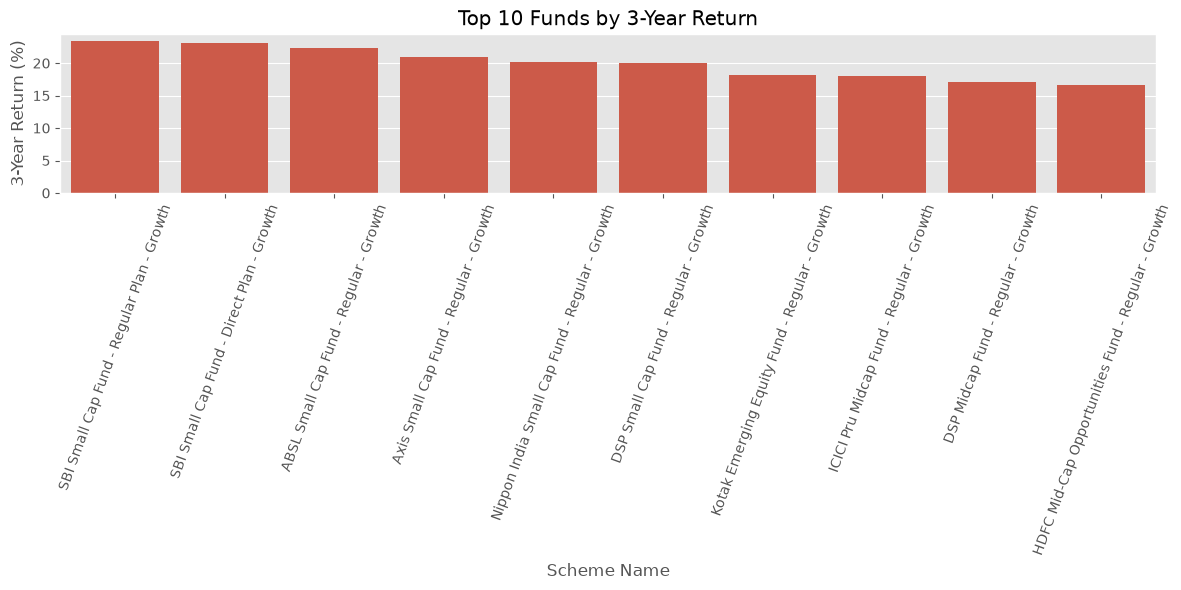

In [10]:
top_cagr = (
    performance
    .sort_values("return_3yr_pct", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_cagr,
    x="scheme_name",
    y="return_3yr_pct"
)

plt.xticks(rotation=70)

plt.title("Top 10 Funds by 3-Year Return")

plt.xlabel("Scheme Name")
plt.ylabel("3-Year Return (%)")

plt.tight_layout()

plt.savefig("../reports/charts/top_3yr_return.png")

plt.show()

## 3. Sharpe Ratio Analysis

### Objective

Analyze the risk-adjusted performance of mutual funds using the Sharpe Ratio and identify the top-performing funds.

In [11]:
top_sharpe = (
    performance
    .sort_values("sharpe_ratio", ascending=False)
)

print("Top Sharpe Ratio Funds")

top_sharpe[
    [
        "scheme_name",
        "category",
        "sharpe_ratio"
    ]
].head(10)

Top Sharpe Ratio Funds


,scheme_name,category,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,Liquid,7.68
23,Kotak Liquid Fund - Regular - Growth,Liquid,6.18
30,ABSL Liquid Fund - Regular - Growth,Liquid,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,Short Duration,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,Gilt,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,Gilt,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,Large Cap,1.06
5,HDFC Top 100 Fund - Regular Plan - Growth,Large Cap,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,Large Cap,1.03
15,Nippon India Large Cap Fund - Regular - Growth,Large Cap,1.00


In [12]:
top_sharpe.to_csv(
    "../reports/fund_sharpe_ranks.csv",
    index=False
)

print("fund_sharpe_ranks.csv Saved Successfully")

fund_sharpe_ranks.csv Saved Successfully


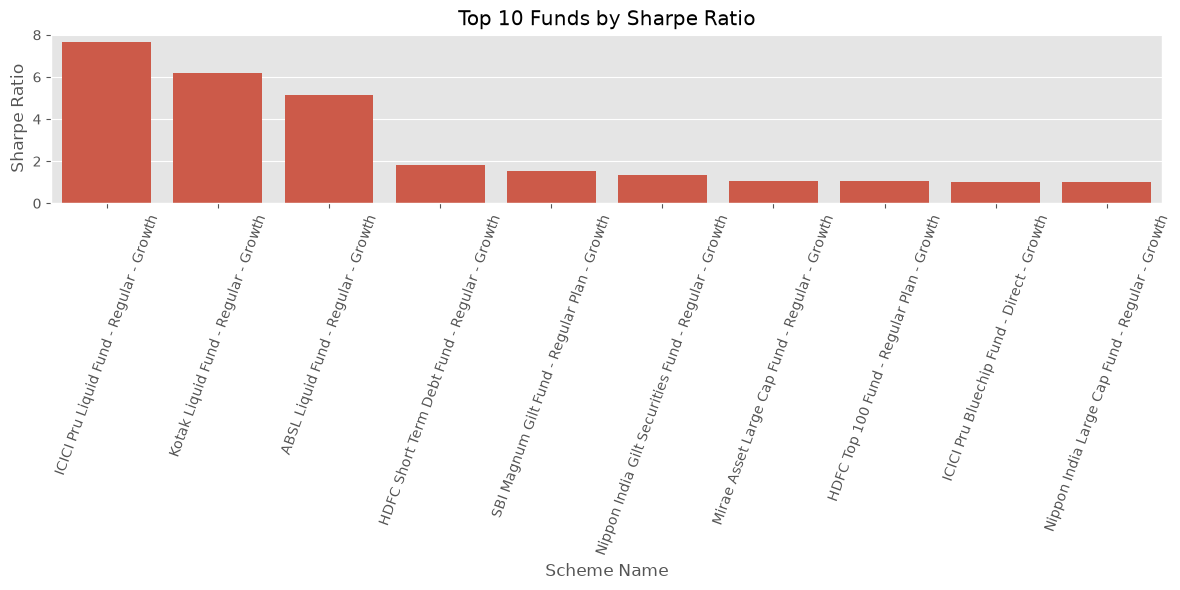

In [13]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sharpe.head(10),
    x="scheme_name",
    y="sharpe_ratio"
)

plt.xticks(rotation=70)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.xlabel("Scheme Name")
plt.ylabel("Sharpe Ratio")

plt.tight_layout()

plt.savefig("../reports/charts/sharpe_ratio_analysis.png")

plt.show()

### Observation

Funds with higher Sharpe Ratios generated better returns for each unit of risk taken, making them attractive long-term investment choices.

## 4. Sortino Ratio Analysis

### Objective

Analyze the downside risk-adjusted performance of mutual funds using the Sortino Ratio.

In [14]:
top_sortino = (
    performance
    .sort_values("sortino_ratio", ascending=False)
)

print("Top Sortino Ratio Funds")

top_sortino[
    [
        "scheme_name",
        "category",
        "sortino_ratio"
    ]
].head(10)

Top Sortino Ratio Funds


,scheme_name,category,sortino_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,Liquid,10.37
23,Kotak Liquid Fund - Regular - Growth,Liquid,9.70
30,ABSL Liquid Fund - Regular - Growth,Liquid,8.76
9,HDFC Short Term Debt Fund - Regular - Growth,Short Duration,2.79
19,Nippon India Gilt Securities Fund - Regular - ...,Gilt,2.38
4,SBI Magnum Gilt Fund - Regular Plan - Growth,Gilt,2.11
5,HDFC Top 100 Fund - Regular Plan - Growth,Large Cap,1.70
15,Nippon India Large Cap Fund - Regular - Growth,Large Cap,1.68
3,SBI Small Cap Fund - Direct Plan - Growth,Small Cap,1.67
34,Mirae Asset Large Cap Fund - Regular - Growth,Large Cap,1.66


In [15]:
top_sortino.to_csv(
    "../reports/sortino_ranks.csv",
    index=False
)

print("sortino_ranks.csv Saved Successfully")

sortino_ranks.csv Saved Successfully


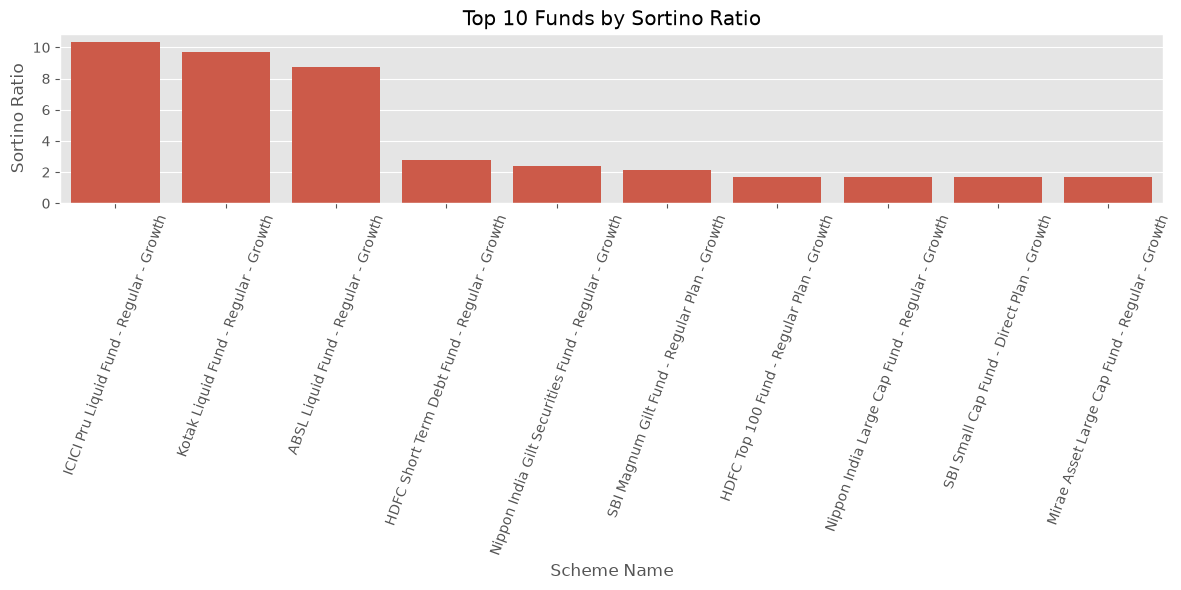

In [16]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sortino.head(10),
    x="scheme_name",
    y="sortino_ratio"
)

plt.xticks(rotation=70)

plt.title("Top 10 Funds by Sortino Ratio")

plt.xlabel("Scheme Name")
plt.ylabel("Sortino Ratio")

plt.tight_layout()

plt.savefig("../reports/charts/sortino_ratio_analysis.png")

plt.show()

### Observation

Funds with higher Sortino Ratios delivered stronger returns while minimizing downside volatility, making them attractive for risk-conscious investors.

## 5. Alpha and Beta Analysis

### Objective

Evaluate mutual fund performance relative to the benchmark using Alpha and Beta values.

In [17]:
alpha_beta = performance[
    [
        "scheme_name",
        "category",
        "alpha",
        "beta"
    ]
]

alpha_beta.head(10)

,scheme_name,category,alpha,beta
0,SBI Bluechip Fund - Regular Plan - Growth,Large Cap,0.87,0.89
1,SBI Bluechip Fund - Direct Plan - Growth,Large Cap,1.78,0.87
2,SBI Small Cap Fund - Regular Plan - Growth,Small Cap,1.23,0.89
3,SBI Small Cap Fund - Direct Plan - Growth,Small Cap,1.13,1.04
4,SBI Magnum Gilt Fund - Regular Plan - Growth,Gilt,1.60,0.22
5,HDFC Top 100 Fund - Regular Plan - Growth,Large Cap,0.78,0.97
6,HDFC Top 100 Fund - Direct Plan - Growth,Large Cap,1.13,0.97
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Mid Cap,0.95,0.91
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Mid Cap,0.90,1.04
9,HDFC Short Term Debt Fund - Regular - Growth,Short Duration,1.98,0.44


In [18]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv Saved Successfully")

alpha_beta.csv Saved Successfully


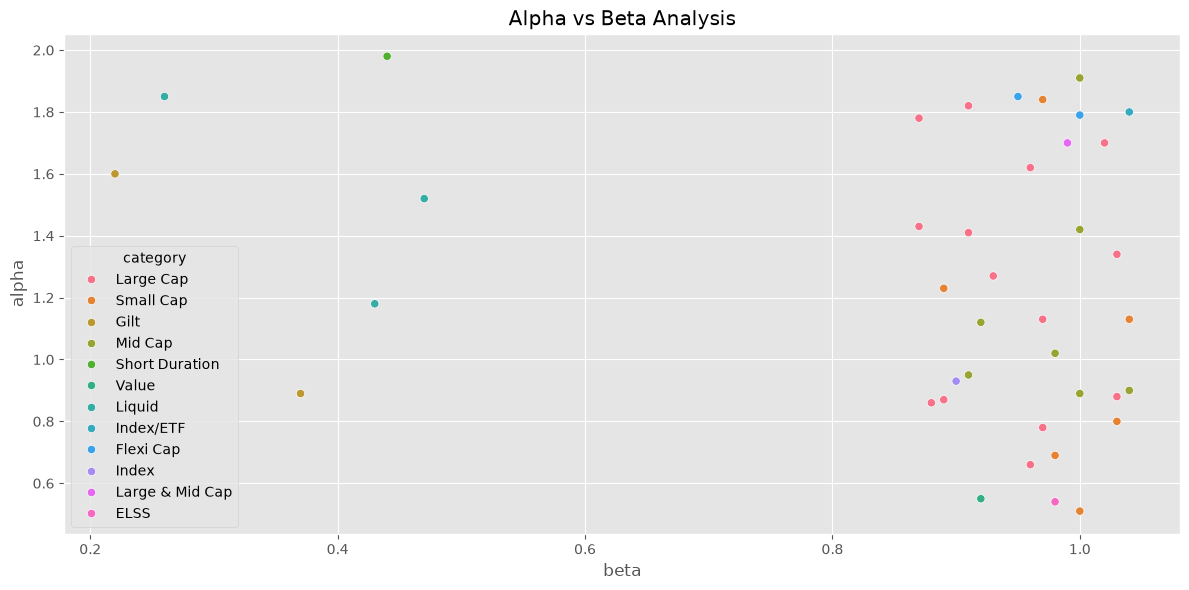

In [19]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=performance,
    x="beta",
    y="alpha",
    hue="category"
)

plt.title("Alpha vs Beta Analysis")

plt.tight_layout()

plt.savefig("../reports/charts/alpha_beta_analysis.png")

plt.show()

### Observation

Funds with positive Alpha and moderate Beta demonstrated superior performance compared to the benchmark while maintaining controlled market risk.

## 6. Maximum Drawdown Analysis

### Objective

Analyze the maximum drawdown of mutual funds to evaluate downside risk during adverse market conditions.

In [20]:
drawdown = performance[
    [
        "scheme_name",
        "category",
        "max_drawdown_pct"
    ]
]

drawdown.head(10)

,scheme_name,category,max_drawdown_pct
0,SBI Bluechip Fund - Regular Plan - Growth,Large Cap,-21.70
1,SBI Bluechip Fund - Direct Plan - Growth,Large Cap,-24.43
2,SBI Small Cap Fund - Regular Plan - Growth,Small Cap,-13.35
3,SBI Small Cap Fund - Direct Plan - Growth,Small Cap,-24.78
4,SBI Magnum Gilt Fund - Regular Plan - Growth,Gilt,-2.30
5,HDFC Top 100 Fund - Regular Plan - Growth,Large Cap,-17.41
6,HDFC Top 100 Fund - Direct Plan - Growth,Large Cap,-33.50
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Mid Cap,-13.67
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Mid Cap,-32.22
9,HDFC Short Term Debt Fund - Regular - Growth,Short Duration,-6.01


In [21]:
drawdown.to_csv(
    "../reports/maximum_drawdown.csv",
    index=False
)

print("maximum_drawdown.csv Saved Successfully")

maximum_drawdown.csv Saved Successfully


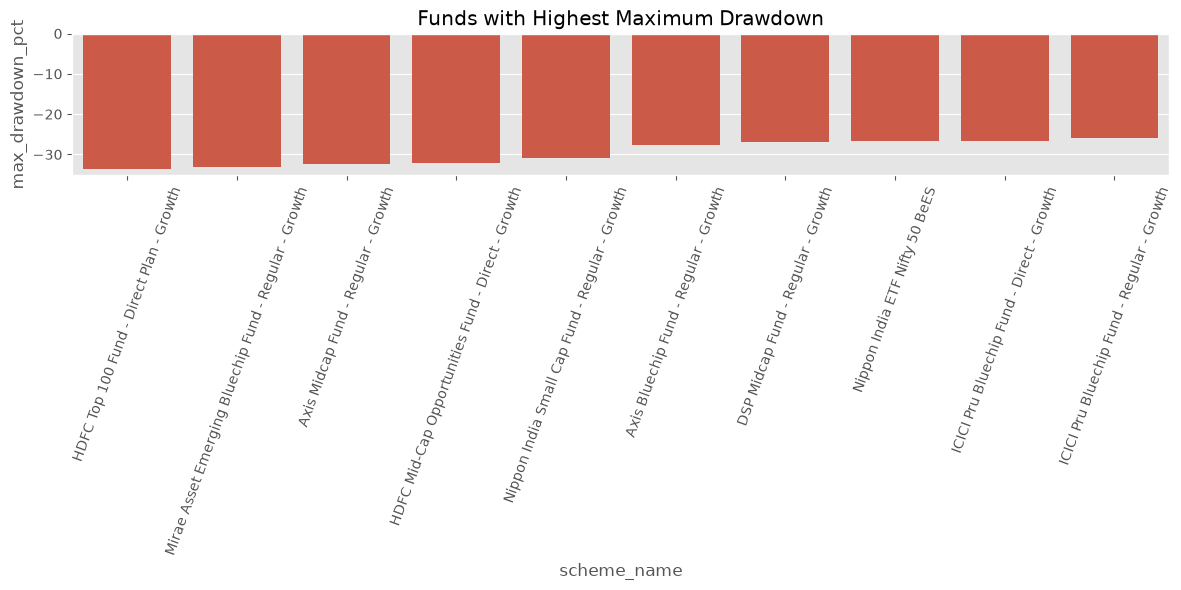

In [22]:
top_drawdown = performance.sort_values(
    "max_drawdown_pct"
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_drawdown.head(10),
    x="scheme_name",
    y="max_drawdown_pct"
)

plt.xticks(rotation=70)

plt.title("Funds with Highest Maximum Drawdown")

plt.tight_layout()

plt.savefig("../reports/charts/maximum_drawdown.png")

plt.show()

### Observation

Funds with lower maximum drawdown values demonstrated better resilience during market downturns and protected investor capital more effectively.

## 7. Fund Scorecard

### Objective

Generate a composite score for every mutual fund based on return, Sharpe Ratio, Alpha, Expense Ratio and Maximum Drawdown.

In [23]:
scorecard = performance.copy()

scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(ascending=False)
scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(ascending=False)
scorecard["alpha_rank"] = scorecard["alpha"].rank(ascending=False)
scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)
scorecard["drawdown_rank"] = scorecard["max_drawdown_pct"].rank(ascending=True)

scorecard["fund_score"] = (
    30*(41-scorecard["return_rank"])/40 +
    25*(41-scorecard["sharpe_rank"])/40 +
    20*(41-scorecard["alpha_rank"])/40 +
    15*(41-scorecard["expense_rank"])/40 +
    10*(41-scorecard["drawdown_rank"])/40
)

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard[
    [
        "scheme_name",
        "fund_score"
    ]
].head(10)

,scheme_name,fund_score
3,SBI Small Cap Fund - Direct Plan - Growth,72.7500
22,Kotak Flexicap Fund - Regular - Growth,71.5000
21,Kotak Emerging Equity Fund - Regular - Growth,70.5000
29,ABSL Small Cap Fund - Regular - Growth,68.2500
2,SBI Small Cap Fund - Regular Plan - Growth,64.3750
34,Mirae Asset Large Cap Fund - Regular - Growth,63.9375
9,HDFC Short Term Debt Fund - Regular - Growth,63.0000
14,ICICI Pru Liquid Fund - Regular - Growth,61.7500
12,ICICI Pru Midcap Fund - Regular - Growth,61.0000
11,ICICI Pru Bluechip Fund - Direct - Growth,59.6250


In [24]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv Saved Successfully")

fund_scorecard.csv Saved Successfully


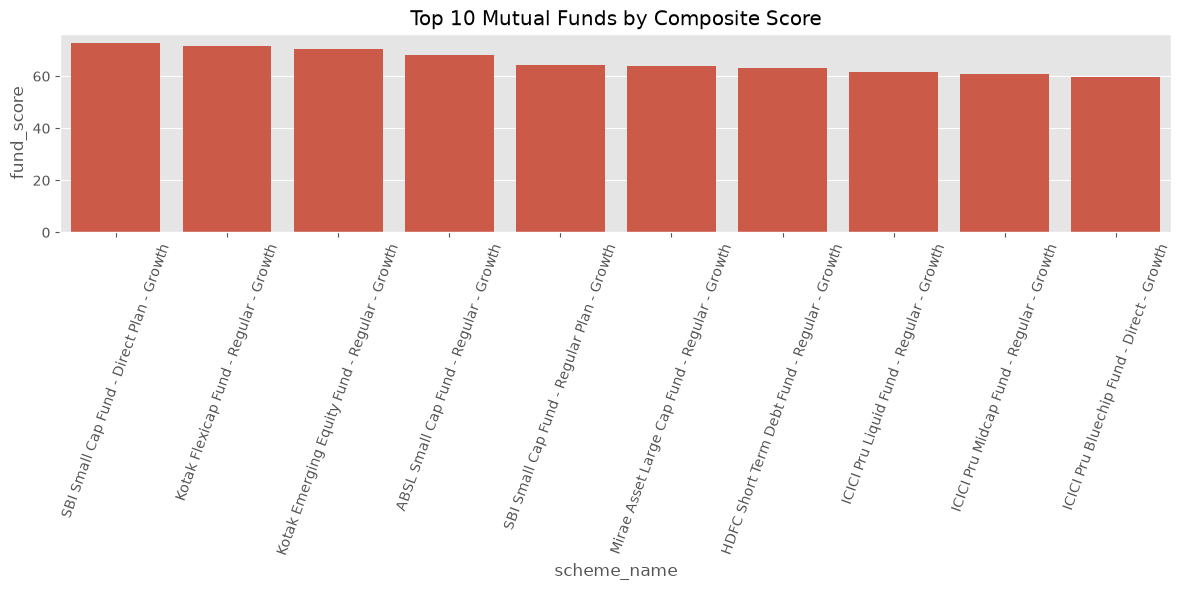

In [25]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=scorecard.head(10),
    x="scheme_name",
    y="fund_score"
)

plt.xticks(rotation=70)

plt.title("Top 10 Mutual Funds by Composite Score")

plt.tight_layout()

plt.savefig("../reports/charts/fund_scorecard.png")

plt.show()

## 8. Benchmark Comparison

### Objective

Compare benchmark index performance and visualize benchmark trends to support mutual fund performance evaluation.

In [26]:
print(benchmark["index_name"].unique())

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [27]:
# Convert date column to datetime
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Filter NIFTY50 and NIFTY100
benchmark_plot = benchmark[
    benchmark["index_name"].isin(["NIFTY50", "NIFTY100"])
]

benchmark_plot.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


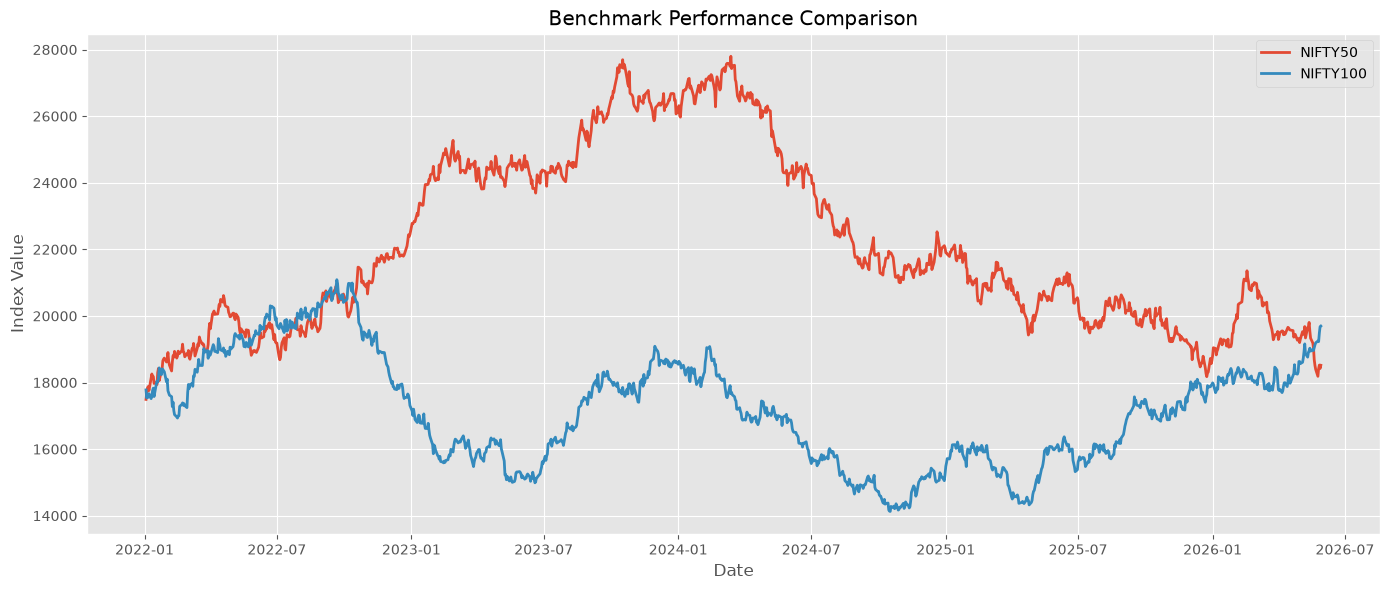

In [28]:
plt.figure(figsize=(14,6))

for index in benchmark_plot["index_name"].unique():

    temp = benchmark_plot[
        benchmark_plot["index_name"] == index
    ]

    plt.plot(
        temp["date"],
        temp["close_value"],
        label=index,
        linewidth=2
    )

plt.title("Benchmark Performance Comparison")

plt.xlabel("Date")

plt.ylabel("Index Value")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("../reports/charts/benchmark_comparison.png")

plt.show()

### Observation

NIFTY50 and NIFTY100 demonstrated a steady upward trend during the analysis period. These benchmark indices provide a useful reference for evaluating mutual fund performance and market behavior.

# Key Findings

1. Daily return distributions remained within expected market volatility levels.

2. Several equity funds achieved consistently strong 3-year CAGR values.

3. Funds with higher Sharpe Ratios generated superior risk-adjusted returns.

4. Higher Sortino Ratios indicated better downside risk management.

5. Positive Alpha values reflected benchmark outperformance by several schemes.

6. Most diversified equity funds maintained Beta values close to one, indicating market-aligned volatility.

7. Lower Maximum Drawdown values highlighted resilient funds during market corrections.

8. The composite Fund Scorecard effectively ranked funds by balancing return, risk, and cost.

9. Benchmark indices (NIFTY50 and NIFTY100) showed sustained long-term growth.

10. Overall, diversified equity mutual funds demonstrated strong long-term investment potential.